In [1]:
from langgraph.graph import START,END,StateGraph
import random
from typing import TypedDict, List

In [2]:
class AgentState(TypedDict):
    name:str
    number:List[int]
    counter:int

In [3]:
def greeting_node(state:AgentState)->AgentState:
    """Greeting node which saye hi to a person"""
    state['name']=f"Hi there,{state['name']}. We will Start the game."
    state['counter']=0
    return state

def random_state(state:AgentState)->AgentState:
    """Generate the number (random) between 0 and 10"""
    state['number'].append(random.randint(0,10))
    state['counter']+=1
    return state

def should_countinue(state:AgentState)->str:
    """Decide what to do next"""
    if state['counter']<5:
        print (f"Enter loop, {state['counter']}")
        return 'loop'
    else:
        print (f"Exit loop, {state['counter']}")
        return 'exit'



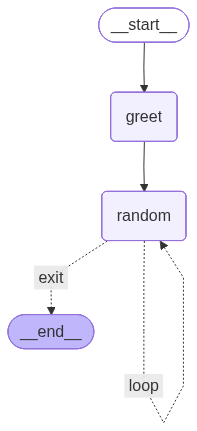

In [4]:
graph=StateGraph(AgentState)
graph.add_node("greet",greeting_node)
graph.add_node("random",random_state)

graph.add_edge(START,"greet")
graph.add_edge("greet","random")
graph.add_conditional_edges(
    "random",
    should_countinue,
    {
        'loop':'random',
        'exit':END
    }
)

graph.add_edge("random",END)

bot=graph.compile()
bot

In [5]:
input_state={
    "name":"Dhruv",
    "number":[]
}
response=bot.invoke(input_state)
print(response)

Enter loop, 1
Enter loop, 2
Enter loop, 3
Enter loop, 4
Exit loop, 5
{'name': 'Hi there,Dhruv. We will Start the game.', 'number': [7, 1, 8, 9, 5], 'counter': 5}
